In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter

plt.style.use('seaborn-v0_8')

In [2]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


In [21]:
data.inc2024.max()

np.float64(1974661.25)

2534984
20567
868
20
2534984
20567
868
20


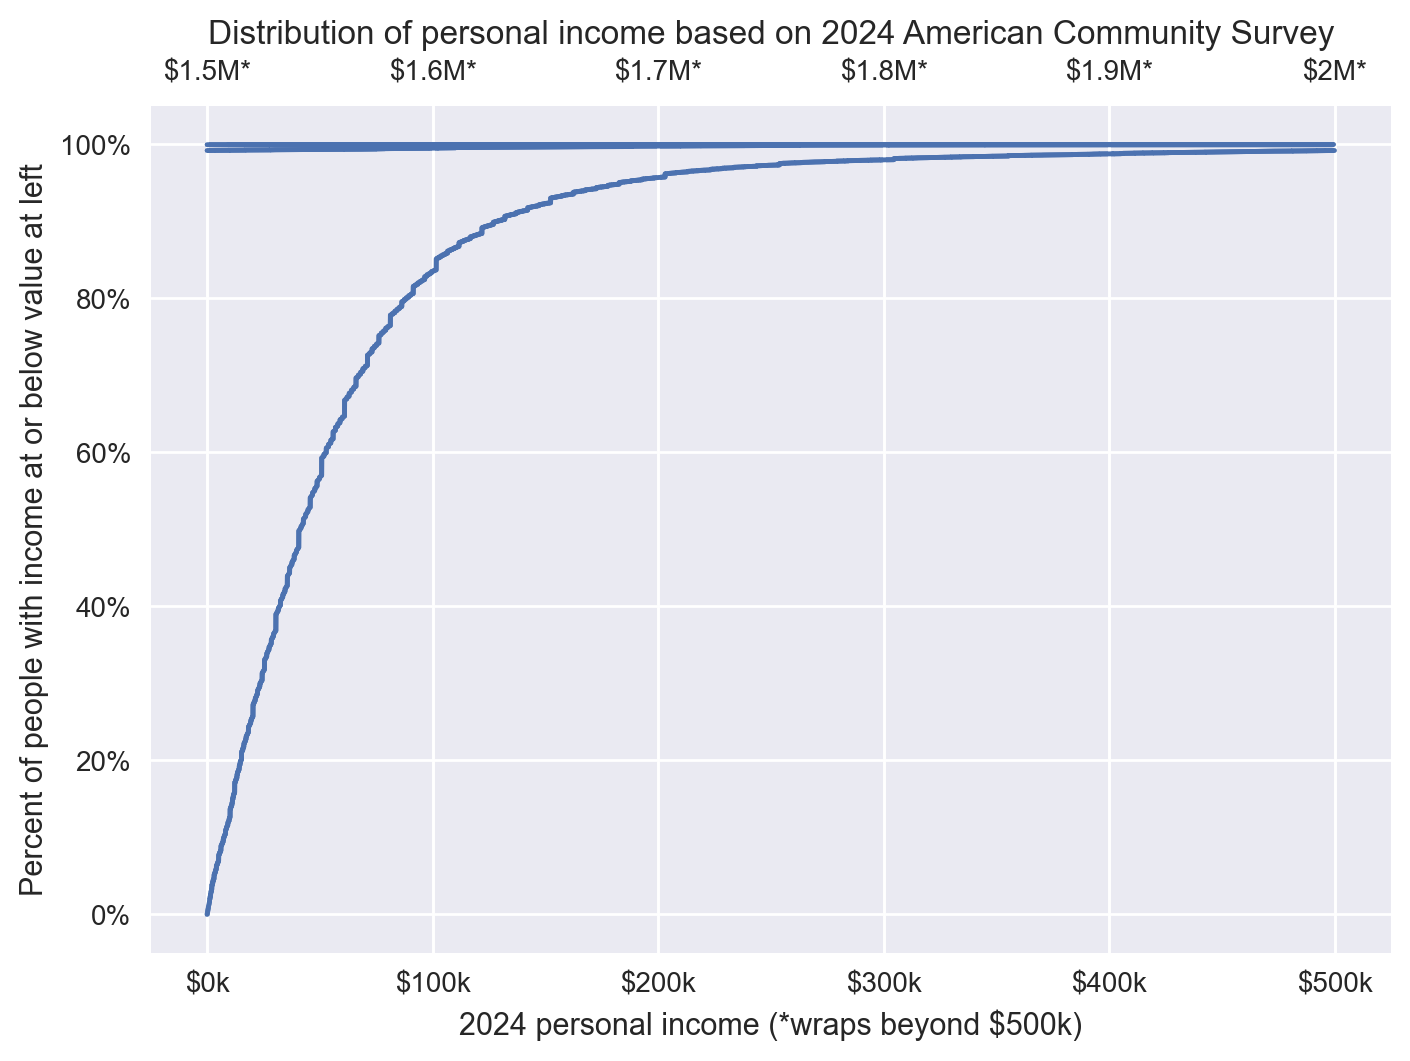

In [30]:
# cmap = plt.get_cmap('cividis')  # 'viridis', 'plasma', 'cividis', etc.
# colors = cmap(np.linspace(0, 1, 6))[::-1]

colors = [
        "#7CFC00",  # bright green (youth)
        "#00BFFF",  # sky blue
        "#FFD700",  # energetic yellow
        "#FF8C00",  # orange
        "#8B4513",  # brown
        "#4B0082",  # deep indigo (old age)
    ]

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    return label

subset = data
subset = subset.sort_values('inc2024')
subset['cum_people'] = subset.PWGTP.cumsum()
total = subset.PWGTP.sum()
for index in range(1, 5):
    smallersubset = subset[(500_000 * (index - 1) < subset.inc2024) & (subset.inc2024 < 500_000 * index)]
    print(len(smallersubset))
    plt.plot(smallersubset.inc2024 % 500_000,
             smallersubset.cum_people / total,
             color='#4C72B0',
#         label=f'People in their {index + 2}0s'
            )
ax = plt.gca()
ax2 = ax.twiny()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
ax.set_xlabel('2024 personal income (*wraps beyond $500k)')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylabel('Percent of people with income at or below value at left')
#plt.legend()
plt.title('Distribution of personal income based on 2024 American Community Survey')

ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ax.get_xticks()[1:-1])
ax2.set_xticklabels(['$1.5M*', '$1.6M*', '$1.7M*', '$1.8M*', '$1.9M*', '$2M*'])

for index in range(1, 5):
    smallersubset = subset[(500_000 * (index - 1) < subset.inc2024) & (subset.inc2024 < 500_000 * index)]
    print(len(smallersubset))
    plt.plot(smallersubset.inc2024 % 500_000,
             smallersubset.cum_people / total,
             color='#4C72B0',
#         label=f'People in their {index + 2}0s'
            )

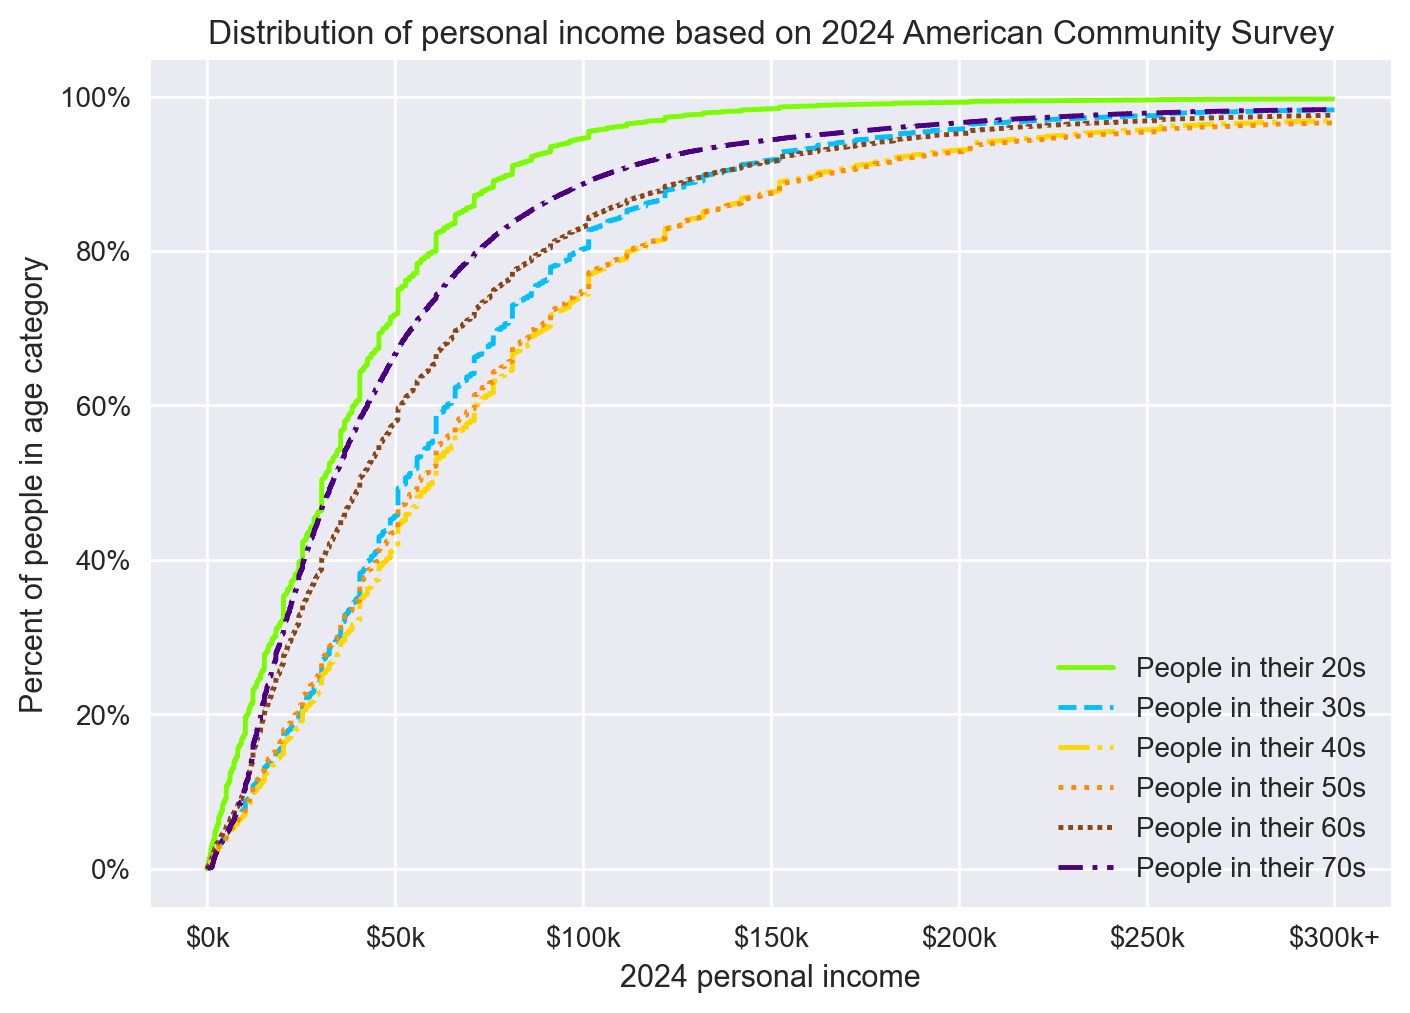

In [39]:
# cmap = plt.get_cmap('cividis')  # 'viridis', 'plasma', 'cividis', etc.
# colors = cmap(np.linspace(0, 1, 6))[::-1]

colors = [
        "#7CFC00",  # bright green (youth)
        "#00BFFF",  # sky blue
        "#FFD700",  # energetic yellow
        "#FF8C00",  # orange
        "#8B4513",  # brown
        "#4B0082",  # deep indigo (old age)
    ]

linestyles = [
    '-',                      # solid
    '--',                     # dashed
    '-.',                     # dash-dot
    ':',                      # dotted
    (0, (1, 1)),              # densely dotted
    (0, (5, 2, 1, 2)),        # dash-dot-dash (custom)
]

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

for index in range(6):
    subset = data[data.AGEP // 10 == (index + 2)]
    subset = subset.sort_values('inc2024')
    subset['cum_people'] = subset.PWGTP.cumsum()
    total = subset.PWGTP.sum()
    plt.plot(subset.inc2024[subset.inc2024 < 300_000],
             subset.cum_people[subset.inc2024 < 300_000] / total,
             color=colors[index],
             linestyle=linestyles[index],
             label=f'People in their {index + 2}0s')

plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.xlabel('2024 personal income')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1))
plt.ylabel('Percent of people in age category')
plt.legend()
plt.title('Distribution of personal income based on 2024 American Community Survey')

plt.show()